Example Plots for Simulated Annealing performed on IEEE57 (with currently 4 generators)

In [20]:
import pandas as pd
brute_force_data = pd.read_csv(
    'data/brute_force/candidate_space_256_instances_2026-03-14_15-30-37.csv'
)

In [21]:
from cl_optimizer import SimulatedAnnealing

# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 100
end_temp = 1
max_temp_iterations = 80

sim_ann = SimulatedAnnealing(
    lookup_table=brute_force_data,
    bounds=[(0, 4)] * 4,
)

optima = []
for iterations in range(1, max_temp_iterations + 1):
    print(f"Temp. Iterations {iterations}")
    temp_schedule = SimulatedAnnealing.geometric_temp_schedule(init_temp, end_temp, iterations)
    _, loss = sim_ann.optimize(
        temp_schedule=temp_schedule,
        verbose=False
    )
    optima.append(loss)

Temp. Iterations 1
Temp. Iterations 2
Temp. Iterations 3
Temp. Iterations 4
Temp. Iterations 5
Temp. Iterations 6
Temp. Iterations 7
Temp. Iterations 8
Temp. Iterations 9
Temp. Iterations 10
Temp. Iterations 11
Temp. Iterations 12
Temp. Iterations 13
Temp. Iterations 14
Temp. Iterations 15
Temp. Iterations 16
Temp. Iterations 17
Temp. Iterations 18
Temp. Iterations 19
Temp. Iterations 20
Temp. Iterations 21
Temp. Iterations 22
Temp. Iterations 23
Temp. Iterations 24
Temp. Iterations 25
Temp. Iterations 26
Temp. Iterations 27
Temp. Iterations 28
Temp. Iterations 29
Temp. Iterations 30
Temp. Iterations 31
Temp. Iterations 32
Temp. Iterations 33
Temp. Iterations 34
Temp. Iterations 35
Temp. Iterations 36
Temp. Iterations 37
Temp. Iterations 38
Temp. Iterations 39
Temp. Iterations 40
Temp. Iterations 41
Temp. Iterations 42
Temp. Iterations 43
Temp. Iterations 44
Temp. Iterations 45
Temp. Iterations 46
Temp. Iterations 47
Temp. Iterations 48
Temp. Iterations 49
Temp. Iterations 50
Temp. Ite

In [22]:
import numpy as np

min_loss = brute_force_data['loss'].min()
max_loss = brute_force_data['loss'].max()
approximation_ratios = 1 - (np.array(optima) - min_loss) / (max_loss - min_loss)

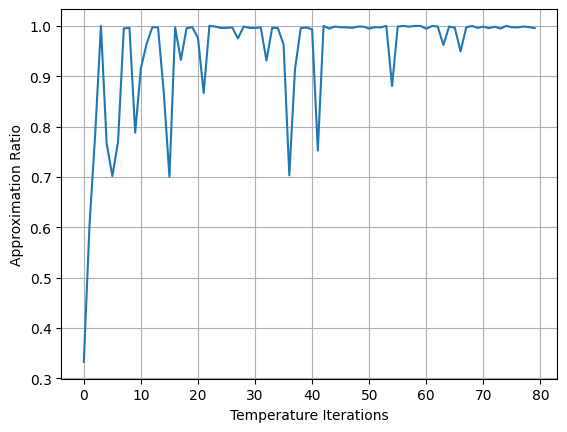

In [23]:
from matplotlib import pyplot as plt

plt.plot(
    range(len(optima)),
    approximation_ratios
)
plt.ylabel('Approximation Ratio')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)